In [ ]:
import warnings
from functools import partial

import iris
import matplotlib.colors as mcol
import matplotlib.pyplot as plt
import numpy as np
import paths
from aeolus.calc import (
    integrate,
    last_n_day_mean,
    spatial,
    spatial_mean,
    toa_net_energy,
    zonal_mean,
)
from aeolus.const import init_const
from aeolus.coord import get_cube_rel_days, interp_cube_from_height_to_pressure_levels
from aeolus.lfric import fix_time_coord, load_lfric_raw, ugrid_spatial
from aeolus.model import lfric
from aeolus.plot import (
    figsave,
    map_scatter,
    timeseries_1d,
    timeseries_2d,
)
from common import (
    EXPERIMENTS,
    lfric_callback_uniform_height,
)

warnings.filterwarnings("ignore")
iris.FUTURE.date_microseconds = True

print(*EXPERIMENTS.keys(), sep="\n")

shj_c48_l32
dhj_c48_l66
hd209_base_c48
shj_base_c48
dhj_base_c24
dhj_base_c48
dhj_base_c96
dhj_base_c192
dhj_base_c24_s0p5_lon00
dhj_base_c24_s0p5_lon90


In [4]:
exp_key = "shj_c48_l32"
ds_init = load_lfric_raw(
    paths.data_work
    / "lfric"
    / EXPERIMENTS[exp_key].group
    / EXPERIMENTS[exp_key].label
    / "lfric_initial.nc",
    # callback=partial(
    #     lfric_callback_uniform_height,
    #     model_top_height=EXPERIMENTS[exp_label].const.domain_height.data,
    # ),
)
print(ds_init)

0: air_density / (kg m-3)              (half_levels: 32; -- : 13824)
1: air_potential_temperature / (K)     (full_levels: 33; -- : 13824)
2: exner_pressure / (1)                (half_levels: 32; -- : 13824)
3: grid_cell_area / (m2)               (-- : 13824)
4: height_of_cell_centres_above_earth_radius / (m) (half_levels: 32; -- : 13824)
5: height_of_cell_interfaces_above_earth_radius / (m) (full_levels: 33; -- : 13824)
6: vapour_mixing_ratio / (kg kg-1)     (full_levels: 33; -- : 13824)


<Axes: >

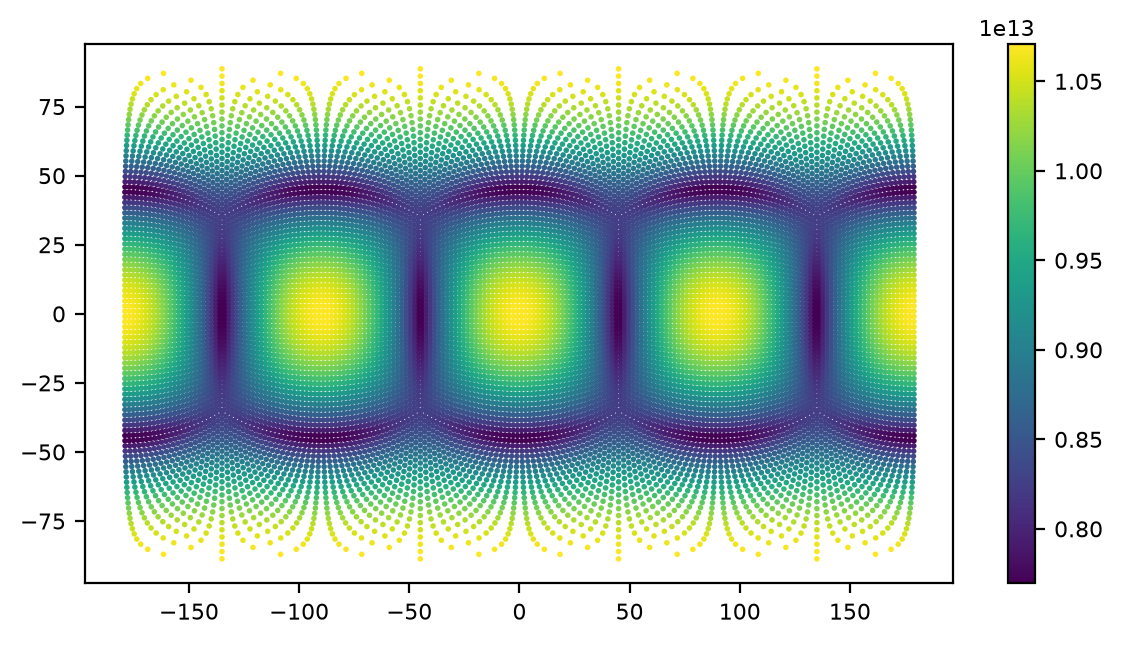

In [5]:
map_scatter(ds_init.extract_cube("grid_cell_area"), s=1)


In [9]:
exp_key = "shj_c48_l32"
ds_main = load_lfric_raw(
    sorted(
        (
            paths.data_work
            / "lfric"
            / EXPERIMENTS[exp_key].group
            / EXPERIMENTS[exp_key].label
        ).glob("lfric_diag_main*.nc")
    )[:],
    callback=partial(
        lfric_callback_uniform_height,
        model_top_height=EXPERIMENTS[exp_key].const.domain_height.data,
    ),
)
print(ds_main)

0: air_pressure / (Pa)                 (time: 27; level_height: 33; -- : 13824)
1: air_temperature / (K)               (time: 27; level_height: 33; -- : 13824)
2: divergence_of_wind / (s-1)          (time: 27; level_height: 32; -- : 13824)
3: eastward_wind / (m s-1)             (time: 27; level_height: 32; -- : 13824)
4: northward_wind / (m s-1)            (time: 27; level_height: 32; -- : 13824)
5: temperature_increment_from_external_forcing / (K) (time: 27; level_height: 33; -- : 13824)
6: upward_air_velocity / (m s-1)       (time: 27; level_height: 32; -- : 13824)
7: vertical_vorticity / (s-1)          (time: 27; level_height: 32; -- : 13824)


Text(0.5, 1.0, 'vertical_vorticity')

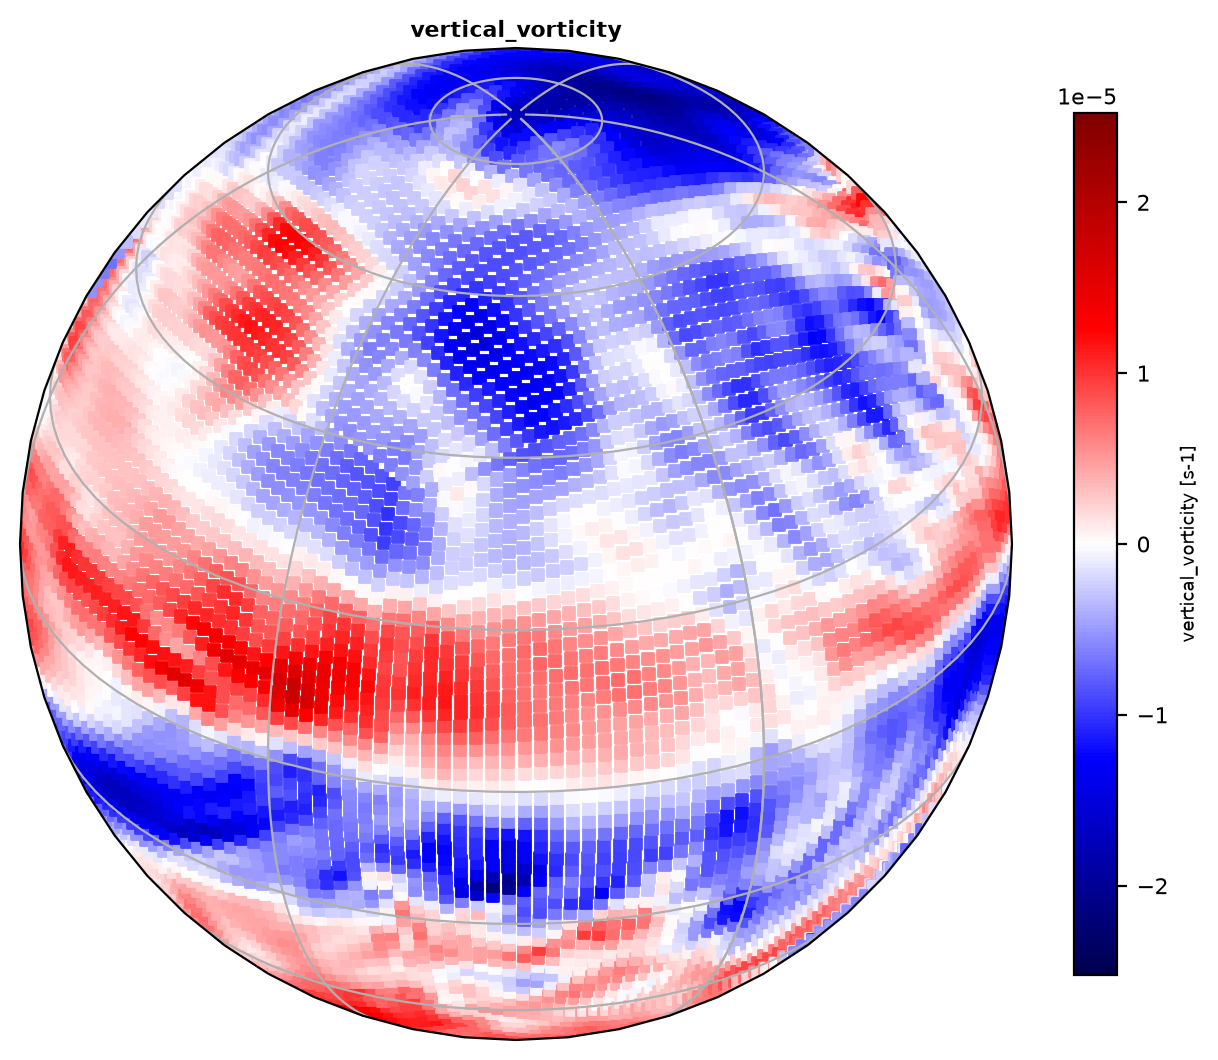

In [ ]:
import cartopy.crs as ccrs

cube = ds_main.extract_cube("vertical_vorticity")[-1, -5, ...]
lons = cube.coord(lfric.x).points
lats = cube.coord(lfric.y).points

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=150, central_latitude=30))
ax.set_global()
ax.gridlines()
mappable = ax.scatter(
    lons,
    lats,
    c=cube.data,
    s=16,
    marker="s",
    transform=ccrs.PlateCarree(),
    norm=mcol.CenteredNorm(),
    cmap="seismic",
)
fig.colorbar(mappable, ax=ax, shrink=0.7, label=f"{cube.name()} [{cube.units}]")
ax.set_title(cube.name())